## 프로젝트 주제 : 재료 + 시간 + 조건 기반 레시피 추천

텍스트/단어로 된 컬럼들(tags, ingredients, description, steps, name, review)을 다각도로 NLP EDA를 진행했습니다.

In [48]:
import pandas as pd
import numpy as np
import ast
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

interactions_df = pd.read_csv('C:/동아리/DArt-B/DArt-B_8th/RAW_interactions.csv')
recipes_df = pd.read_csv('C:/동아리/DArt-B/DArt-B_8th/RAW_recipes.csv')

#### 1. 태그(tags) — NLP 모델 기반 심층 분석

1-1. 준비: 태그 파싱

In [49]:
def parse_list_col(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

recipes_df["tags_parsed"] = recipes_df["tags"].apply(parse_list_col)
all_tags_list = [tag for lst in recipes_df["tags_parsed"] for tag in lst]
unique_tags = set(all_tags_list)
tags = sorted(list(unique_tags))
tag_counter = Counter(all_tags_list)

print(f"전체 고유 태그 개수: {len(unique_tags)}개")

전체 고유 태그 개수: 552개


1-2. 문장 임베딩으로 태그 간 "의미적 유사도" 파악

단순 빈도가 아니라, 태그를 벡터 공간에 임베딩해서 의미적으로 비슷한 태그들이 실제로 가깝게 묶이는지 확인합니다.

In [50]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")  # 가볍고 빠른 임베딩 모델

tag_texts = [t.replace("-", " ") for t in tags]
tag_embeddings = embed_model.encode(tag_texts, show_progress_bar=True)

print(tag_embeddings.shape)  # (고유 태그 수, 384)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

(552, 384)


1-3. 임베딩 기반 클러스터링 (KMeans) — 태그의 "자연스러운" 그룹 발견

zero-shot처럼 카테고리를 미리 정해두는 게 아니라, 모델이 데이터 자체에서 그룹을 찾아내게 합니다.

In [51]:
from sklearn.cluster import KMeans

n_clusters = 10  # 실험적으로 조정 가능
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tag_embeddings)

tag_cluster_df = pd.DataFrame({"tag": tags, "cluster": cluster_labels})

# 클러스터별 대표 태그(빈도 상위) 확인
for c in range(n_clusters):
    cluster_tags = tag_cluster_df[tag_cluster_df["cluster"] == c]["tag"].tolist()
    cluster_tags_sorted = sorted(cluster_tags, key=lambda t: tag_counter[t], reverse=True)
    print(f"\n[Cluster {c}] 대표 태그: {cluster_tags_sorted[:10]}")

c:\Users\Kang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(



[Cluster 0] 대표 태그: ['pasta-rice-and-grains', 'pasta', 'soups-stews', 'beans', 'rice', 'grains', 'corn', 'spaghetti', 'black-beans', 'green-yellow-beans']

[Cluster 1] 대표 태그: ['american', 'european', 'asian', 'italian', 'canadian', 'australian', 'indian', 'greek', 'french', 'chinese']

[Cluster 2] 대표 태그: ['cuisine', 'main-dish', 'meat', 'vegetarian', 'beginner-cook', 'poultry', 'chicken', 'beef', 'pork', 'potluck']

[Cluster 3] 대표 태그: ['main-ingredient', 'dietary', 'low-sodium', 'low-carb', 'healthy', 'low-cholesterol', 'low-calorie', '5-ingredients-or-less', 'low-protein', 'low-saturated-fat']

[Cluster 4] 대표 태그: ['seafood', 'fish', 'shellfish', 'saltwater-fish', 'shrimp', 'salmon', 'tuna', 'crab', 'freshwater-fish', 'wings']

[Cluster 5] 대표 태그: ['number-of-servings', 'desserts', 'oven', 'side-dishes', 'comfort-food', 'appetizers', 'one-dish-meal', 'cheese', 'breads', 'cookies-and-brownies']

[Cluster 6] 대표 태그: ['preparation', 'time-to-make', 'course', 'easy', 'low-in-something', 'equ

1-4. 클러스터 시각화 (t-SNE 2D)

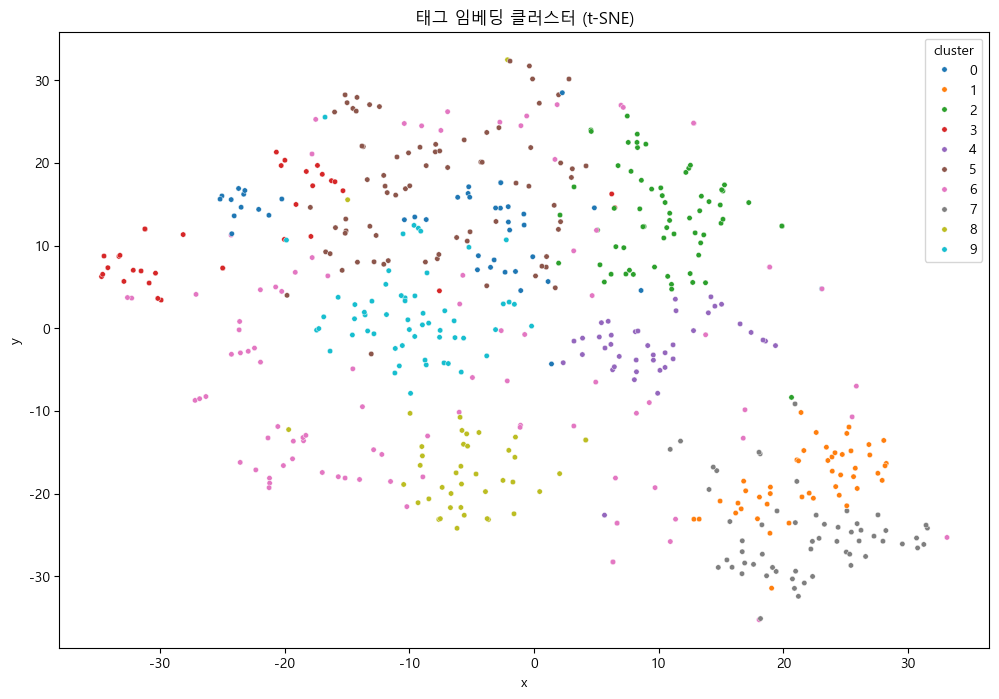

In [52]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tag_2d = tsne.fit_transform(tag_embeddings)

tag_cluster_df["x"] = tag_2d[:, 0]
tag_cluster_df["y"] = tag_2d[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=tag_cluster_df, x="x", y="y", hue="cluster", palette="tab10", s=15, legend="full")
plt.title("태그 임베딩 클러스터 (t-SNE)")
plt.show()

1-5. zero-shot 분류와 클러스터링 결과 비교 (모델 관점 vs 데이터 관점)

앞서 만든 zero-shot 결과(df_pivot)와 클러스터 결과를 합쳐서, 사람이 정한 카테고리(zero-shot)와 모델이 스스로 찾은 그룹(클러스터링)이 얼마나 일치하는지 비교합니다.

In [54]:
tags = [t for t in tags if isinstance(t, str) and t.strip() != ""]
print(f"정리 후 태그 개수: {len(tags)}개")

zero_shot_results = []
for tag in tags:
    output = classifier1(
        tag.replace("-", " "),
        candidate_labels=list(candidate_labels)
    )
    zero_shot_results.append(output["labels"][0])

tag_cluster_df = tag_cluster_df[tag_cluster_df["tag"].isin(tags)].copy()
tag_cluster_df["zero_shot_category"] = zero_shot_results

정리 후 태그 개수: 551개


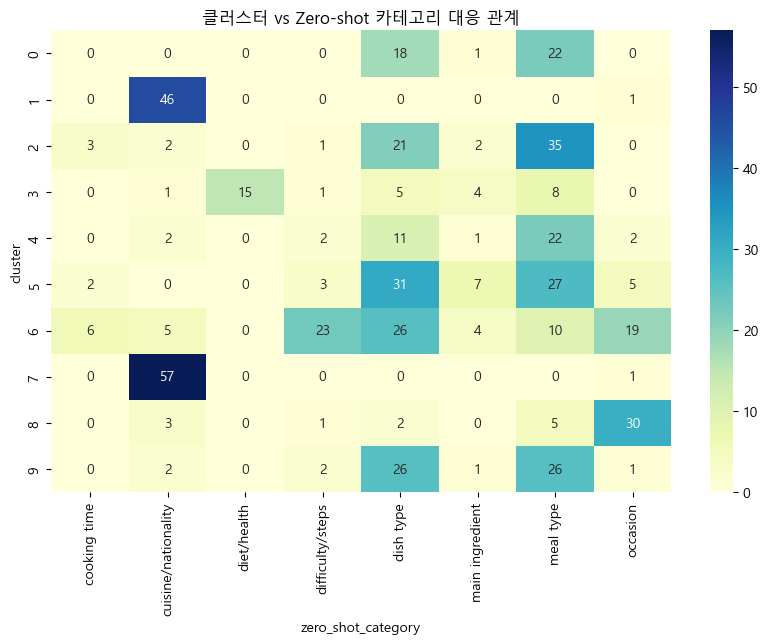

In [55]:
cross_tab = pd.crosstab(tag_cluster_df["cluster"], tag_cluster_df["zero_shot_category"])
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("클러스터 vs Zero-shot 카테고리 대응 관계")
plt.show()

#### 2. 재료(Ingredients) - 임베딩 기반 클러스터링

재료는 종류가 훨씬 다양해서, "비슷한 재료군"(예: 유제품류, 향신료류, 채소류)이 자연스럽게 묶이는지 확인합니다.

In [56]:
recipes_df["ingredients_parsed"] = recipes_df["ingredients"].apply(parse_list_col)
all_ingredients = [ing for lst in recipes_df["ingredients_parsed"] for ing in lst if ing.strip() != ""]
unique_ingredients = sorted(set(all_ingredients))
ingredient_counter = Counter(all_ingredients)

print(f"고유 재료 개수: {len(unique_ingredients)}개")

# 재료가 너무 많으면 빈도 상위 N개만 임베딩 (전체 다 하면 오래 걸림)
top_n_ingredients = [i for i, _ in ingredient_counter.most_common(500)]

ing_embeddings = embed_model.encode(top_n_ingredients, show_progress_bar=True)

kmeans_ing = KMeans(n_clusters=12, random_state=42, n_init=10)
ing_cluster_labels = kmeans_ing.fit_predict(ing_embeddings)

ing_cluster_df = pd.DataFrame({"ingredient": top_n_ingredients, "cluster": ing_cluster_labels})

for c in range(12):
    sample = ing_cluster_df[ing_cluster_df["cluster"] == c]["ingredient"].tolist()[:10]
    print(f"[Cluster {c}] {sample}")

고유 재료 개수: 14942개


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

c:\Users\Kang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


[Cluster 0] ['ground cinnamon', 'ground cumin', 'ground beef', 'ground ginger', 'ginger', 'ground nutmeg', 'lean ground beef', 'beef broth', 'ground coriander', 'ham']
[Cluster 1] ['butter', 'milk', 'parmesan cheese', 'sour cream', 'cream cheese', 'cheddar cheese', 'unsalted butter', 'paprika', 'bacon', 'heavy cream']
[Cluster 2] ['celery', 'soy sauce', 'mayonnaise', 'worcestershire sauce', 'chili powder', 'dijon mustard', 'tomato sauce', 'tomato paste', 'cumin', 'ketchup']
[Cluster 3] ['pepper', 'salt and pepper', 'black pepper', 'fresh ground black pepper', 'cayenne pepper', 'red bell pepper', 'green pepper', 'ground black pepper', 'green bell pepper', 'fresh ground pepper']
[Cluster 4] ['salt', 'onion', 'garlic cloves', 'garlic', 'garlic powder', 'onions', 'garlic clove', 'green onions', 'red onion', 'green onion']
[Cluster 5] ['sugar', 'flour', 'brown sugar', 'all-purpose flour', 'baking powder', 'baking soda', 'cornstarch', 'granulated sugar', 'powdered sugar', 'white sugar']
[Clu

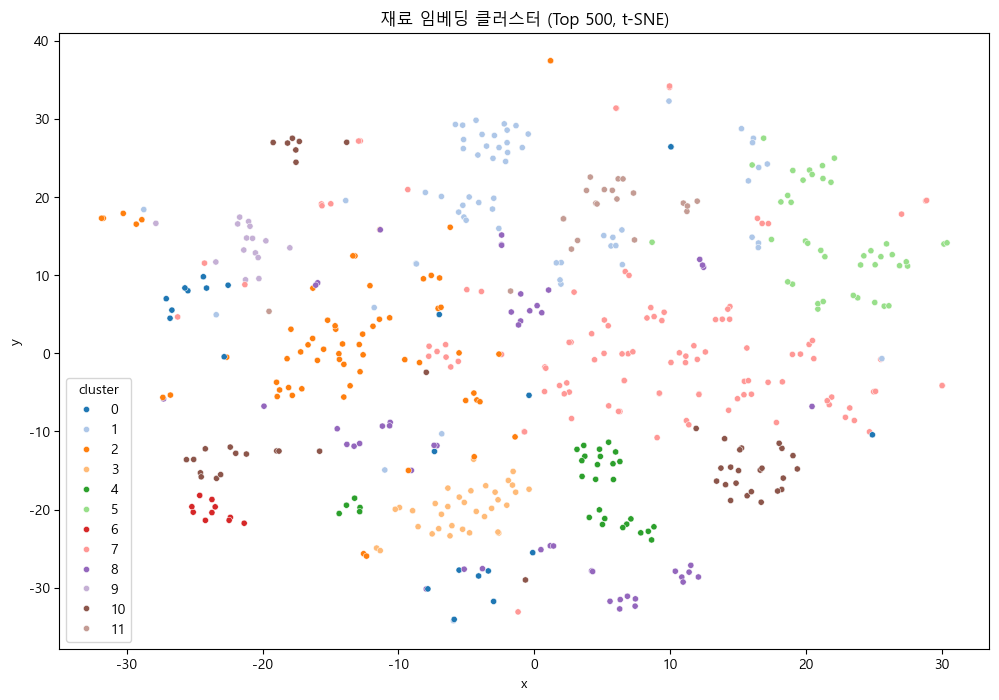

In [57]:
tsne_ing = TSNE(n_components=2, random_state=42, perplexity=30)
ing_2d = tsne_ing.fit_transform(ing_embeddings)
ing_cluster_df["x"], ing_cluster_df["y"] = ing_2d[:, 0], ing_2d[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=ing_cluster_df, x="x", y="y", hue="cluster", palette="tab20", s=20, legend="full")
plt.title("재료 임베딩 클러스터 (Top 500, t-SNE)")
plt.show()

#### 3. 설명(description) — 문장 임베딩 + 클러스터링 + 대표 키워드

In [58]:
desc_sample = recipes_df["description"].dropna()
desc_sample = desc_sample[desc_sample.str.strip() != ""].sample(2000, random_state=42)

desc_embeddings = embed_model.encode(desc_sample.tolist(), show_progress_bar=True, batch_size=32)

kmeans_desc = KMeans(n_clusters=8, random_state=42, n_init=10)
desc_cluster_labels = kmeans_desc.fit_predict(desc_embeddings)

desc_cluster_df = pd.DataFrame({"description": desc_sample.values, "cluster": desc_cluster_labels})

# 클러스터별 TF-IDF로 대표 키워드 추출
from sklearn.feature_extraction.text import TfidfVectorizer

for c in range(8):
    texts = desc_cluster_df[desc_cluster_df["cluster"] == c]["description"]
    if len(texts) < 5:
        continue
    tfidf = TfidfVectorizer(max_features=10, stop_words="english")
    tfidf.fit(texts)
    print(f"[Cluster {c}] (n={len(texts)}) 대표 키워드: {list(tfidf.get_feature_names_out())}")

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

c:\Users\Kang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


[Cluster 0] (n=126) 대표 키워드: ['add', 'cheese', 'dressing', 'fresh', 'great', 'like', 'make', 'recipe', 'salad', 'use']
[Cluster 1] (n=221) 대표 키워드: ['com', 'easy', 'family', 'favorite', 'good', 'great', 'like', 'magazine', 'posted', 'time']
[Cluster 2] (n=409) 대표 키워드: ['cheese', 'dish', 'great', 'just', 'like', 'make', 'recipe', 'sauce', 'time', 'use']
[Cluster 3] (n=138) 대표 키워드: ['cake', 'dessert', 'easy', 'great', 'just', 'like', 'make', 'pie', 'recipe', 'time']
[Cluster 4] (n=252) 대표 키워드: ['chicken', 'cooking', 'easy', 'good', 'great', 'make', 'recipe', 'soup', 'time', 'use']
[Cluster 5] (n=275) 대표 키워드: ['bread', 'cookies', 'easy', 'good', 'great', 'like', 'make', 'recipe', 'time', 'use']
[Cluster 6] (n=253) 대표 키워드: ['cream', 'delicious', 'good', 'great', 'just', 'like', 'make', 'recipe', 'time', 'use']
[Cluster 7] (n=326) 대표 키워드: ['easy', 'family', 'good', 'got', 'great', 'like', 'love', 'make', 'recipe', 'time']


#### 4. 리뷰(review) - 감성분석 + 별점 관계 심화

In [59]:
sentiment_clf = pipeline("sentiment-analysis")

sample_reviews = df[["rating", "review"]].dropna()
sample_reviews = sample_reviews[sample_reviews["review"].str.strip() != ""].sample(1000, random_state=42)

def get_sentiment(text):
    result = sentiment_clf(str(text)[:512])[0]
    return result["label"], result["score"]

sentiment_results = sample_reviews["review"].apply(get_sentiment)
sample_reviews["sentiment"] = sentiment_results.apply(lambda x: x[0])
sample_reviews["sentiment_score"] = sentiment_results.apply(lambda x: x[1])

# 별점과 감성 예측이 어긋나는(리뷰는 긍정인데 별점 낮음 등) 케이스 찾기
mismatch = sample_reviews[
    ((sample_reviews["rating"] <= 2) & (sample_reviews["sentiment"] == "POSITIVE")) |
    ((sample_reviews["rating"] >= 4) & (sample_reviews["sentiment"] == "NEGATIVE"))
]
print(f"별점-감성 불일치 리뷰 수: {len(mismatch)} / {len(sample_reviews)}")
mismatch[["rating", "review", "sentiment", "sentiment_score"]].head(10)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

별점-감성 불일치 리뷰 수: 147 / 1000


,rating,review,sentiment,sentiment_score
575196,4,This is a very cute idea. I made this for DH w...,NEGATIVE,0.741393
1062587,4,I made as written and the flavor of this was e...,NEGATIVE,0.979281
857526,5,O'kay I scaled back for 3 serves but didn.t th...,NEGATIVE,0.858771
1108980,0,"I think this was a good idea, but I too had to...",POSITIVE,0.998435
991011,4,This recipe is very much like the one that I u...,NEGATIVE,0.986271
794407,5,This is a great recipe. I was looking for som...,NEGATIVE,0.628317
824393,5,"My sauce was a little thick, so I added some e...",NEGATIVE,0.976839
1046431,2,I made this recipe exactly as it says except I...,POSITIVE,0.700042
737247,5,I put all this in my crock pot with some extra...,NEGATIVE,0.977016
783921,5,The perfect way to make banana bread in the br...,NEGATIVE,0.979571


#### 5. 조리 단계(Steps) - 문장 수 vs 복잡도, TF-IDF 핵심 동사

In [60]:
recipes_df["steps_parsed"] = recipes_df["steps"].apply(parse_list_col)
recipes_df["steps_text"] = recipes_df["steps_parsed"].apply(lambda x: " ".join(x))

sample_steps = recipes_df["steps_text"].sample(5000, random_state=42)
tfidf_steps = TfidfVectorizer(max_features=30, stop_words="english")
tfidf_matrix = tfidf_steps.fit_transform(sample_steps)

scores = tfidf_matrix.sum(axis=0).A1
tfidf_step_df = pd.DataFrame({"word": tfidf_steps.get_feature_names_out(), "score": scores})
tfidf_step_df.sort_values("score", ascending=False).head(20)

,word,score
0,add,917.409113
14,minutes,772.032088
10,heat,647.465823
15,mix,584.078260
27,stir,526.023081
11,ingredients,520.875397
3,bowl,505.973899
8,cook,502.635479
16,mixture,484.878202
21,place,483.922408


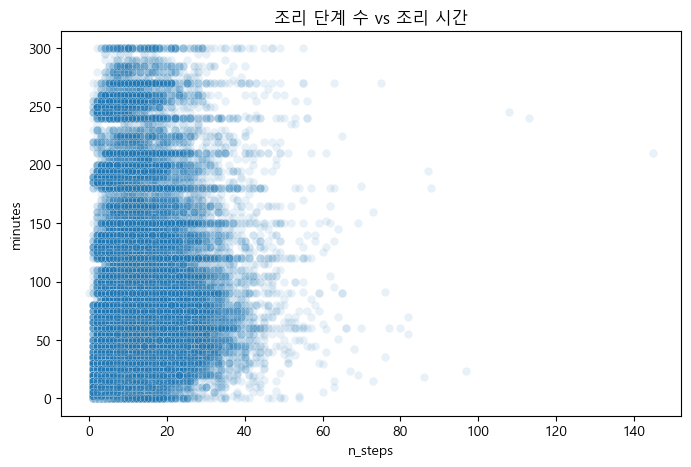

In [61]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=recipes_df[recipes_df["minutes"] <= 300], x="n_steps", y="minutes", alpha=0.1)
plt.title("조리 단계 수 vs 조리 시간")
plt.show()